In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("C:/Users/tarun/Downloads/Titanic.csv")

# Basic exploration
print(df.info())
print(df.describe())
df. isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.48659

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
# Calculate median age
median_age = df['Age'].median()

# Fill missing values correctly
df['Age'] = df['Age'].fillna(median_age)
print("Missing Age values:", df['Age'].isnull().sum())
df.drop(columns=['Cabin'], inplace=True)

Missing Age values: 0


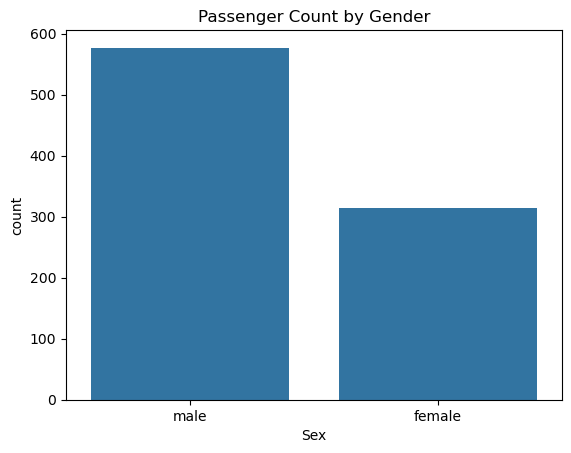

In [12]:
# Q1. Create a countplot to show the number of passengers by gender.
# Ans:1
sns.countplot(x='Sex', data=df,)
plt.title("Passenger Count by Gender")
plt.show()


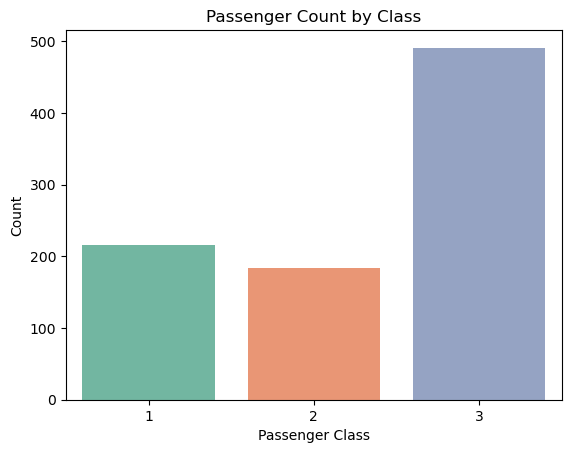

In [13]:
# Q2. Create a bar chart to show the number of passengers in each passenger class using different colors.
# Ans:2
# Q2: Bar chart - Passengers by Class
sns.countplot(x='Pclass', data=df, hue='Pclass', palette='Set2', legend=False)
plt.title("Passenger Count by Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()


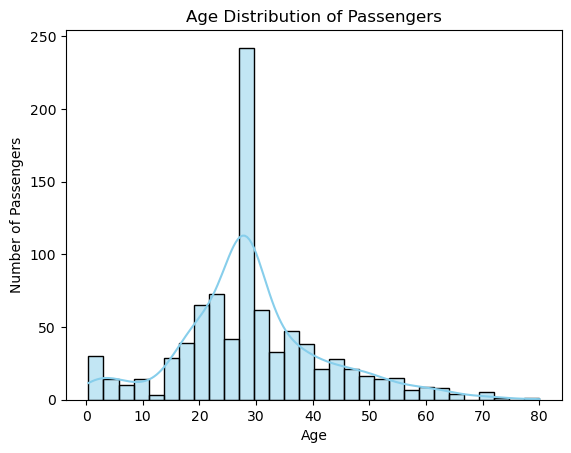

In [15]:
# Q3. Create a histogram to show the distribution of passenger age.
# Ans:3 
# Q3: Histogram - Age Distribution
sns.histplot(df['Age'], bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Passengers")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")
plt.show()


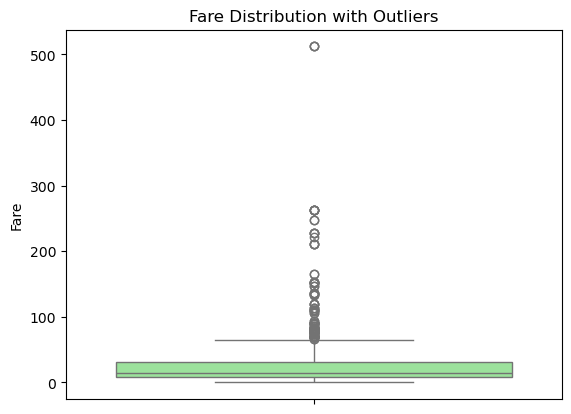

In [16]:
# Q4. Create a boxplot to detect outliers in the fare column.
# Ans:4 
# Q4: Boxplot - Fare Outliers
sns.boxplot(y='Fare', data=df, color='lightgreen')
plt.title("Fare Distribution with Outliers")
plt.ylabel("Fare")
plt.show()


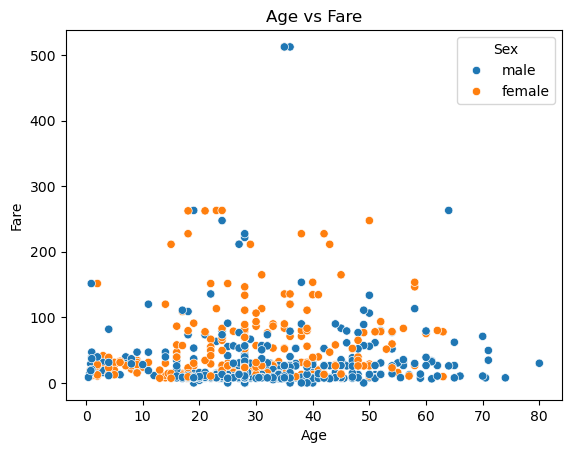

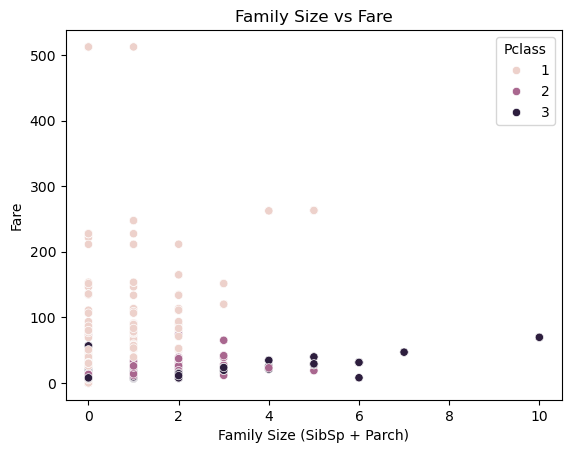

In [17]:
# Q5. Create a scatterplot to 
# a. show the relationship between age and fare.
# b. analyze the relationship between family size (SibSp + Parch) and fare.
# Ans:5
# Q5a: Scatterplot - Age vs Fare
sns.scatterplot(x='Age', y='Fare', data=df, hue='Sex')
plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")
plt.show()
# Create FamilySize column
df['FamilySize'] = df['SibSp'] + df['Parch']

# Scatterplot - Family Size vs Fare
sns.scatterplot(x='FamilySize', y='Fare', data=df, hue='Pclass')
plt.title("Family Size vs Fare")
plt.xlabel("Family Size (SibSp + Parch)")
plt.ylabel("Fare")
plt.show()


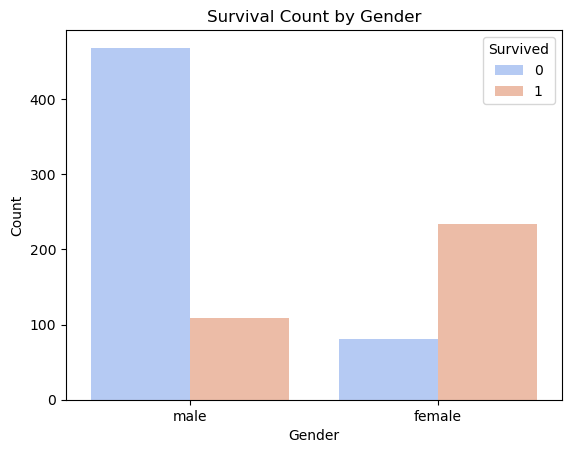

In [18]:
# Q6. Create a countplot to show survival count by gender.
# Ans:6
# Q6: Countplot - Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=df, palette='coolwarm')
plt.title("Survival Count by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()


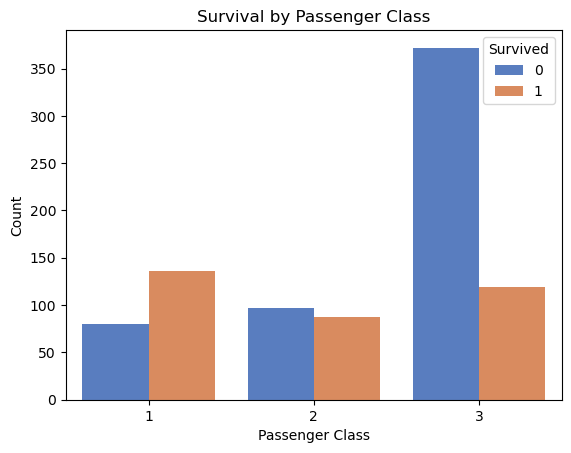

In [19]:
# Q7. Create a bar chart to show survival by passenger class
# Ans:7
# Q7: Bar chart - Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=df, palette='muted')
plt.title("Survival by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Count")
plt.show()


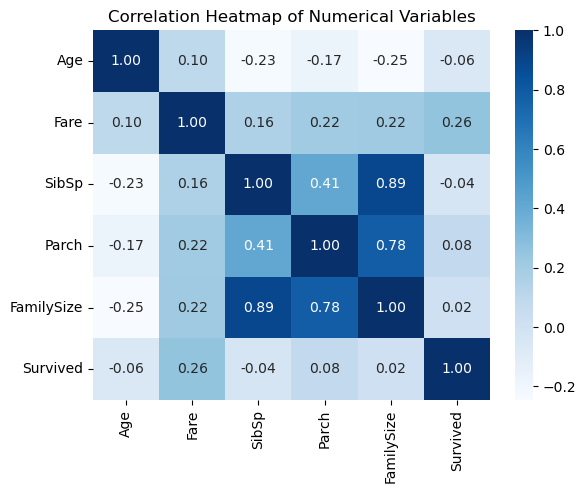

In [20]:
# Q8. Create a heatmap to show correlation between numerical variables.
# Ans:8
# Q8: Heatmap - Correlation between numerical variables
corr = df[['Age','Fare','SibSp','Parch','FamilySize','Survived']].corr()

sns.heatmap(corr, annot=True, cmap='Blues', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()


Average Fare by Class:
 Pclass
1    84.154687
2    20.662183
3    13.675550
Name: Fare, dtype: float64


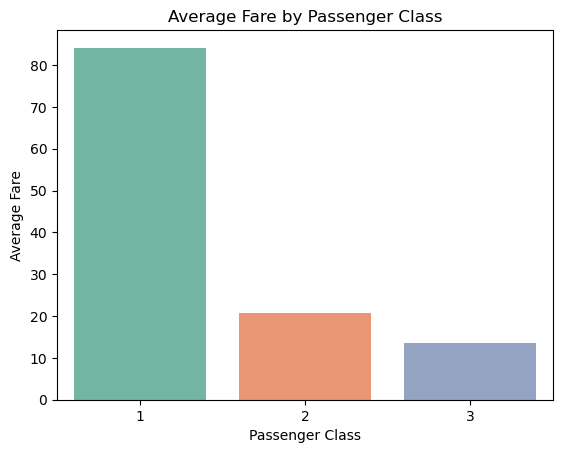

In [22]:
# Q9. Identify which passenger class paid the highest fare on average.
# Ans: 9
# Q9: Highest Average Fare by Passenger Class
avg_fare = df.groupby('Pclass')['Fare'].mean()
print("Average Fare by Class:\n", avg_fare)

# Optional: Bar chart for better visualization
# Q9: Average Fare by Class (fixed palette warning)
sns.barplot(x=avg_fare.index, y=avg_fare.values, hue=avg_fare.index, palette='Set2', legend=False)
plt.title("Average Fare by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Average Fare")
plt.show()

In [ ]:
# Q10. Write at least 5 insights from the dataset based on your visualizations.
# Ans:10
# Gender Distribution & Survival
# Males were the majority onboard, but females had a much higher survival rate.
# This reflects the “women and children first” evacuation policy.
# Passenger Class & Survival

Most passengers were in 3rd class, while 1st class had the fewest.

1st class passengers had the highest survival rate, showing that wealth and social status influenced survival chances.

Age Distribution

Majority of passengers were between 20–40 years old.

Younger passengers had slightly better survival chances compared to older ones.

Fare & Outliers

Most fares were low, but 1st class passengers paid extremely high fares (outliers above 200).

Higher fares correlated positively with survival, meaning wealthier passengers had better access to lifeboats.

Family Size & Fare

Most passengers traveled alone or with small families (0–2).

Larger families often paid higher fares, especially in 1st class, but family size had weak correlation with survival.